## Independent fish: noisy escape and recovery

Each fish combines a deterministic evidence increment with Gaussian noise:

$$d_i = \frac{\Delta t}{\tau}\left[L_i(t) - x_i(t)\right],
\qquad \Delta x_i = d_i + \sigma \sqrt{\Delta t}\,\xi_{i,t}.$$

Here, $x_i$ is `fish.evidence`, $L_i$ is that fish's input, $\tau$ is
`tau_evidence`, and $\sigma$ is `noise_strength`. Each $\xi_{i,t}$ is a
standard normal draw, independent across fish and timesteps. The square-root
scaling makes the noise variance proportional to the timestep duration.
Time is in seconds.

Sheltered and unsheltered fish use the same evidence update. The deterministic
part pulls evidence toward the perceived input strength, or toward zero when
input is absent. Evidence can rise or fall in either state, with noise added
at every timestep. Evidence retains memory through the leaky update even
though successive noise draws are independent.

State only determines which behavioral threshold applies. Reaching `threshold`
while unsheltered triggers escape. A sheltered fish recovers strictly below
`recovery_threshold`, including when noise causes the crossing.

Only the first `n_exposed` fish receive the stimulus. All fish receive independent
noise, so their responses differ. Evidence can fluctuate below zero, and noise
can also trigger escapes in unexposed fish. There is no social coupling.

`random_seed` makes runs reproducible; setting `noise_strength` to zero gives
the deterministic response. The fish class is defined in [agent.py](agent.py).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from agent import Agent

In [2]:
## Group size, timing, and state thresholds
n_fish = 20
total_time = 1.0
dt = 0.001
tau_evidence = 0.1
threshold = 0.5
recovery_threshold = 0.1

In [3]:
## Evidence noise
noise_strength = 0.2
random_seed = 2026

In [4]:
## External stimulus
n_exposed = 5
stimulus_start = 0.2
stimulus_duration = 0.3
stimulus_strength = 1.0

The simulation uses exactly `n_steps` updates, indexed from `0` through
`n_steps - 1`. Times mark update starts; histories store results after each update.

In [5]:
n_steps = round(total_time / dt)
time = np.arange(n_steps) * dt

In [6]:
external_input = np.zeros(n_steps)
stimulus_end = stimulus_start + stimulus_duration
pulse_active = (time >= stimulus_start) & (time < stimulus_end)
external_input[pulse_active] = stimulus_strength

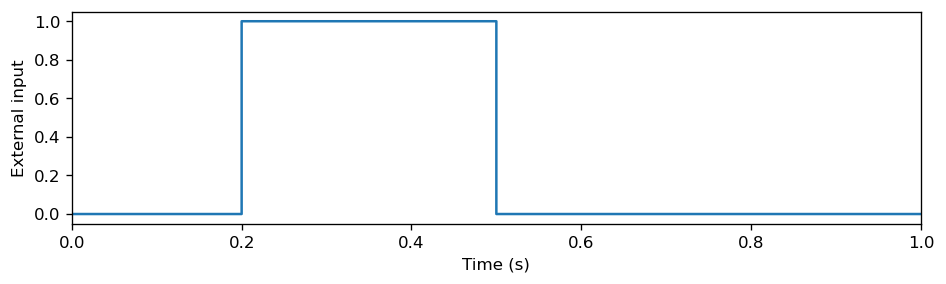

In [7]:
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.step(time, external_input, where="post")
ax.set(xlim=(0, total_time), xlabel="Time (s)", ylabel="External input")
fig.tight_layout()
plt.show()

In [8]:
evidence_history = np.zeros((n_fish, n_steps))
escape_spikes = np.zeros((n_fish, n_steps))
state_history = np.zeros((n_fish, n_steps))

History rows represent fish and columns represent timesteps. Escape spikes
mark transitions into shelter; recovery occurs below `recovery_threshold`.

In [9]:
agents = [Agent() for _ in range(n_fish)]
rng = np.random.default_rng(random_seed)

for step in range(n_steps):
    for fish_id, fish in enumerate(agents):
        fish_input = external_input[step] if fish_id < n_exposed else 0.0
        change = (fish_input - fish.evidence) / tau_evidence * dt
        change += noise_strength * np.sqrt(dt) * rng.normal()
        fish.evidence += change
        if fish.state == 0:
            if fish.evidence >= threshold:
                fish.state = 1
                escape_spikes[fish_id, step] = 1
        elif fish.evidence < recovery_threshold:
            fish.state = 0
        evidence_history[fish_id, step] = fish.evidence
        state_history[fish_id, step] = fish.state

## Evidence over time

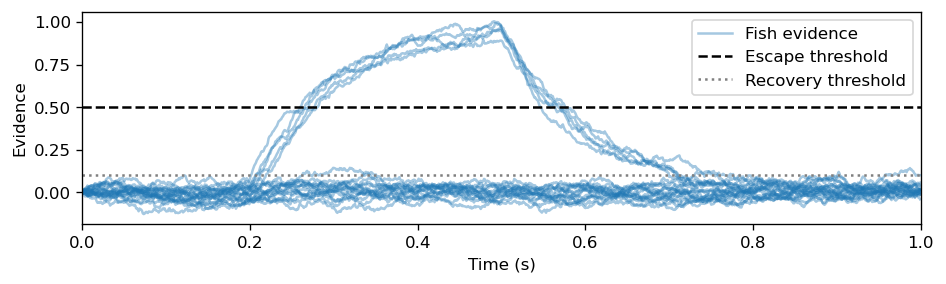

In [10]:
fig, ax = plt.subplots(figsize=(8, 2.5))
lines = ax.plot(time, evidence_history.T, color="tab:blue", alpha=0.4)
lines[0].set_label("Fish evidence")
ax.axhline(threshold, color="black", linestyle="--", label="Escape threshold")
ax.axhline(recovery_threshold, color="grey", linestyle=":",
           label="Recovery threshold")
ax.set(xlim=(0, total_time), xlabel="Time (s)", ylabel="Evidence")
ax.legend()
fig.tight_layout()
plt.show()

## Escape spikes

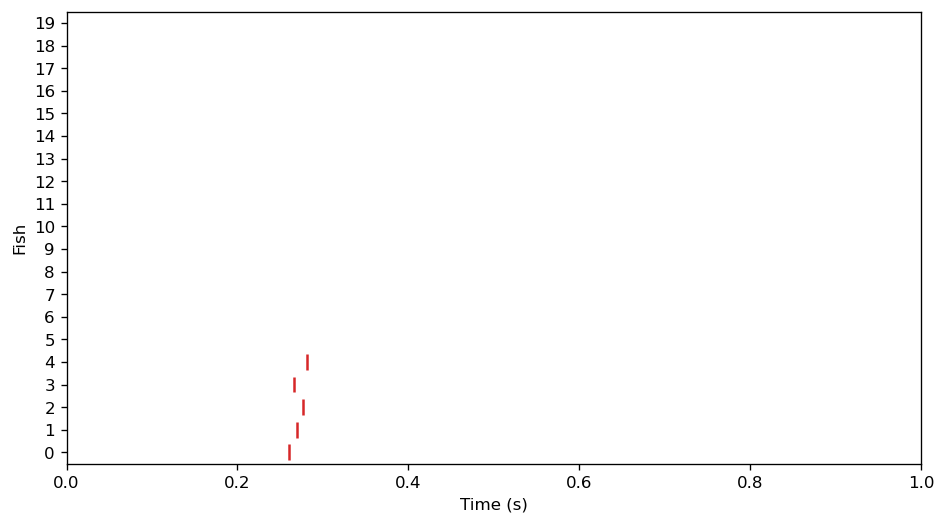

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for fish_id in range(n_fish):
    escape_times = time[escape_spikes[fish_id] == 1]
    ax.vlines(escape_times, fish_id - 0.35, fish_id + 0.35, color="tab:red")
ax.set(xlim=(0, total_time), ylim=(-0.5, n_fish - 0.5))
ax.set(xlabel="Time (s)", ylabel="Fish", yticks=np.arange(n_fish))
fig.tight_layout()
plt.show()

## Shelter state

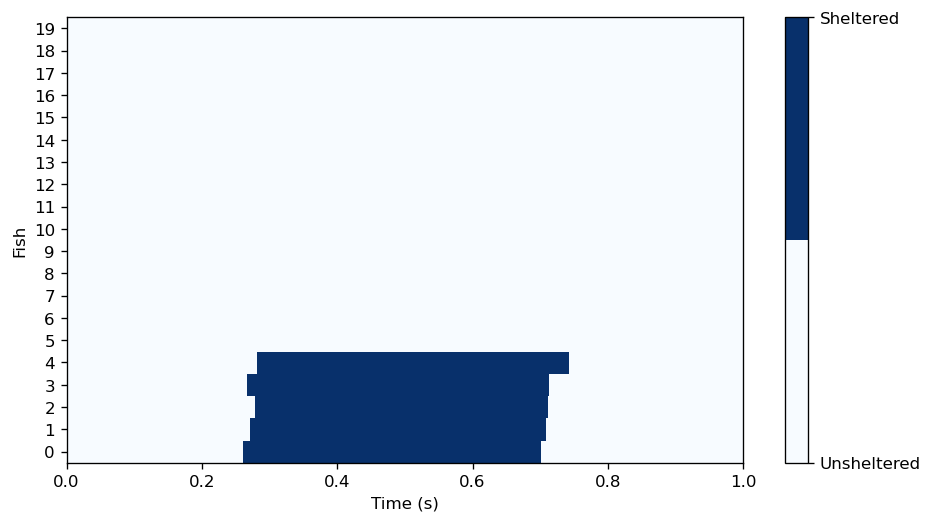

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
image = ax.imshow(state_history, origin="lower", aspect="auto",
                  extent=(0, total_time, -0.5, n_fish - 0.5),
                  cmap=plt.get_cmap("Blues", 2), vmin=0, vmax=1,
                  interpolation="nearest")
ax.set(xlabel="Time (s)", ylabel="Fish", yticks=np.arange(n_fish))
colorbar = fig.colorbar(image, ax=ax, ticks=[0, 1])
colorbar.ax.set_yticklabels(["Unsheltered", "Sheltered"])
fig.tight_layout()
plt.show()